# QTransLIFIA — Quirk → OpenQASM 2.0

Prueba los algoritmos cuánticos del repositorio. Traduce circuitos de [Quirk](https://algassert.com/quirk) a OpenQASM 2.0.

In [1]:
!pip install qiskit
!pip install matplotlib
!pip install qiskit_aer

In [2]:
import os, sys
import importlib
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils import qutils
qutils = importlib.reload(qutils)

parse_quirk_url = qutils.parse_quirk_url
quirk_col_to_qasm = qutils.quirk_col_to_qasm
quirk_to_qasm = qutils.quirk_to_qasm
quirk_circuit_info = qutils.quirk_circuit_info
encode_quirk_url = qutils.encode_quirk_url
append_custom_gates = qutils.append_custom_gates


In [ ]:
# @title 2. Funciones auxiliares
from IPython.display import display, Markdown
import json

ALGORITHMS = {
    "0. Prueba": {
        "desc": "Algoritmo de Prueba",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}",
        "offset": 0
    },
    "1. Shor": {
        "desc": "Algoritmo de factorización de Shor (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\",\"H\"],[\"X\"],[\"X\",\"X\",\"X\",\"X\"],[1,\"•\",\"X\"],[1,\"X\",\"•\"],[1,\"•\",\"X\"],[1,1,\"•\",\"X\"],[1,1,\"X\",\"•\"],[1,1,\"•\",\"X\"],[\"•\",1,1,\"X\"],[\"X\",1,1,\"•\"],[\"•\",1,1,\"X\"],[\"Measure\",\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "2. Bernstein-Vazirani": {
        "desc": "Algoritmo de Bernstein-Vazirani (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,1,1,\"X\"],[1,1,1,\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,\"X\"],[1,1,\"•\",\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "3. Grover": {
        "desc": "Algoritmo de búsqueda de Grover (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\"],[1,\"X\"],[1,\"H\"],[\"•\",\"X\"],[1,\"H\"],[1,\"X\"],[1,\"H\"],[1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "4. Deutsch-Jozsa": {
        "desc": "Algoritmo de Deutsch-Jozsa (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"X\",1,\"X\",\"X\"],[1,1,1,\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,\"X\"],[1,1,\"•\",\"X\"],[\"X\",1,\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "5. Simon": {
        "desc": "Algoritmo de Simon (6 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"•\",1,1,\"X\"],[1,\"•\",1,1,\"X\"],[1,1,\"•\",1,1,\"X\"],[1,\"•\",1,1,\"X\"],[1,\"•\",1,1,1,\"X\"],[\"H\",\"H\",\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "6. TSP": {
        "desc": "Circuito para problema del viajante (TSP, 3 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\"],[1,\"X\",\"X\"],[\"X\",\"•\"],[\"X\",1,\"•\"],[\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "7. Teleportation": {
        "desc": "Protocolo de teleportación cuántica (5 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[1,\"H\"],[1,\"•\",1,1,\"X\"],[\"H\"],[\"•\",\"X\"],[\"H\"],[\"Measure\",\"Measure\"],[1,\"•\",1,1,\"X\"],[\"•\",1,1,1,\"Z\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "8. Phase Estimation": {
        "desc": "Estimación de fase cuántica (4 qubits + compuertas custom)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,1,1,\"X\"],[\"•\",1,1,\"Z^¼\"],[1,\"•\",1,\"Z^¼\"],[1,\"•\",1,\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[1,1,\"•\",\"Z^¼\"],[\"Swap\",1,\"Swap\"],[\"H\"],[\"•\",\"~16c9\"],[1,\"H\"],[\"•\",1,\"~gf1o\"],[1,\"•\",\"~16c9\"],[1,1,\"H\"],[\"Measure\",\"Measure\",\"Measure\"]],\"gates\":[{\"id\":\"~gf1o\",\"name\":\"U(-pi/4)\",\"matrix\":\"{{1,0},{0,√½-√½i}}\"},{\"id\":\"~16c9\",\"name\":\"U(-pi/2)\",\"matrix\":\"{{1,0},{0,-i}}\"},{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "9. QFT": {
        "desc": "Transformada de Fourier Cuántica (3 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[1,\"X\",\"X\"],[\"H\"],[\"Z\",\"•\"],[\"Z^½\",1,\"•\"],[1,\"H\"],[1,\"Z\",\"•\"],[1,1,\"H\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "10. QAOA": {
        "desc": "Quantum Approximate Optimization Algorithm (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"Rxft\",\"Rxft\"],[],[\"•\",\"X\"],[\"Rxft\",\"Rxft\"],[],[1,\"Rxft\"],[],[\"•\",\"X\"],[\"Rxft\"],[],[1,\"Measure\"],[\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "11. Kickback": {
        "desc": "Phase kickback (2 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[1,\"X\"],[\"H\",\"H\"],[\"•\",\"X\"],[\"H\",\"H\"],[\"Measure\"],[1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    },
    "12. Full Adder": {
        "desc": "Sumador completo (4 qubits)",
        "url": "https://algassert.com/quirk#circuit={\"cols\":[[\"H\",\"H\",\"H\"],[\"•\",\"•\",1,\"X\"],[\"•\",\"X\"],[1,\"•\",\"•\",\"X\"],[1,\"•\",\"X\"],[\"•\",\"X\"],[\"Measure\"],[1,\"Measure\"],[1,1,\"Measure\"],[1,1,1,\"Measure\"]],\"gates\":[{\"id\":\"~rvcr\",\"name\":\"MultiX\",\"circuit\":{\"cols\":[[\"•\",\"•\",\"X\",\"•\"]]}}]}",
        "offset": 0
    }
}

def _md(value):
    """Convierte un valor a texto seguro para una tabla Markdown."""
    if value is None:
        return "-"
    return str(value).replace("|", "\\|").replace("\n", "<br>")

def describe_algorithms():
    summary = [
        '| # | Algoritmo | Qubits | Columnas | Compuertas | Custom | IDs custom | Nombres custom | Compuertas internas |',
        '|---:|---|---:|---:|---|---:|---|---|---|'
    ]
    details = [
        '### Detalle de compuertas custom',
        '| Algoritmo | ID | Nombre | Qubits | Columnas | Matriz | Circuito interno |',
        '|---|---|---|---:|---:|---|---|'
    ]

    for key, algorithm in ALGORITHMS.items():
        info = quirk_circuit_info(algorithm['url'])
        number, name = key.split('. ', 1)
        summary.append(
            f'| {number} | **{_md(name)}** | {info["n_qubits"]} | {info["n_cols"]} |'
            f' {_md(", ".join(info["gates"]))} | {info["n_custom_gates"]} |'
            f' {_md(", ".join(info["custom_gate_ids"]))} |'
            f' {_md(", ".join(info["custom_gate_names"]))} |'
            f' {_md(", ".join(info["custom_gates_gates"]))} |'
        )

        for gate_info in info['custom_gates_info']:
            details.append(
                f'| **{_md(name)}** | {_md(gate_info["id"])} |'
                f' {_md(gate_info["name"])} | {_md(gate_info["n_qubits"])} |'
                f' {_md(gate_info["n_cols"])} | {_md(gate_info["matrix"])} |'
                f' {_md(gate_info["circuit_cols"])} |'
            )

        raw_custom_gates = json.dumps(info['custom_gates'], ensure_ascii=False)
        details.append(f'| **{_md(name)}** | Definiciones completas | - | - | - | - | {_md(raw_custom_gates)} |')

    display(Markdown('\n'.join(summary + ['', *details])))

In [15]:
# @title 3. Listar algoritmos disponibles
describe_algorithms()

| # | Algoritmo | Qubits | Columnas | Compuertas | Custom | IDs custom | Nombres custom | Compuertas internas |
|---:|---|---:|---:|---|---:|---|---|---|
| 0 | **Prueba** | 4 | 13 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 1 | **Shor** | 4 | 13 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 2 | **Bernstein-Vazirani** | 4 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 3 | **Grover** | 2 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 4 | **Deutsch-Jozsa** | 4 | 9 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 5 | **Simon** | 6 | 8 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 6 | **TSP** | 3 | 6 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 7 | **Teleportation** | 5 | 8 | H, Measure, X, Z, • | 1 | ~rvcr | MultiX | X, • |
| 8 | **Phase Estimation** | 4 | 17 | H, Measure, Swap, X, Z^¼, ~16c9, ~gf1o, • | 3 | ~gf1o, ~16c9, ~rvcr | U(-pi/4), U(-pi/2), MultiX | X, • |
| 9 | **QFT** | 3 | 8 | H, X, Z, Z^½, • | 1 | ~rvcr | MultiX | X, • |
| 10 | **QAOA** | 2 | 12 | Measure, Rxft, X, • | 1 | ~rvcr | MultiX | X, • |
| 11 | **Kickback** | 2 | 6 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |
| 12 | **Full Adder** | 4 | 10 | H, Measure, X, • | 1 | ~rvcr | MultiX | X, • |

### Detalle de compuertas custom
| Algoritmo | ID | Nombre | Qubits | Columnas | Matriz | Circuito interno |
|---|---|---|---:|---:|---|---|
| **Prueba** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Prueba** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Shor** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Shor** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Bernstein-Vazirani** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Bernstein-Vazirani** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Grover** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Grover** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Deutsch-Jozsa** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Deutsch-Jozsa** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Simon** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Simon** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **TSP** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **TSP** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Teleportation** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Teleportation** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Phase Estimation** | ~gf1o | U(-pi/4) | - | - | {{1,0},{0,√½-√½i}} | - |
| **Phase Estimation** | ~16c9 | U(-pi/2) | - | - | {{1,0},{0,-i}} | - |
| **Phase Estimation** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Phase Estimation** | Definiciones completas | - | - | - | - | [{"id": "~gf1o", "name": "U(-pi/4)", "matrix": "{{1,0},{0,√½-√½i}}"}, {"id": "~16c9", "name": "U(-pi/2)", "matrix": "{{1,0},{0,-i}}"}, {"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **QFT** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **QFT** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **QAOA** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **QAOA** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Kickback** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Kickback** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |
| **Full Adder** | ~rvcr | MultiX | 4 | 1 | - | [['•', '•', 'X', '•']] |
| **Full Adder** | Definiciones completas | - | - | - | - | [{"id": "~rvcr", "name": "MultiX", "circuit": {"cols": [["•", "•", "X", "•"]]}}] |

In [16]:
# @title 4. Probar un algoritmo individual
ALGO = "0. Prueba"  # @param ["1. Shor", "2. Bernstein-Vazirani", "3. Grover", "4. Deutsch-Jozsa", "5. Simon", "6. TSP", "7. Teleportation", "8. Phase Estimation", "9. QFT", "10. QAOA", "11. Kickback", "12. Full Adder"]

algo = ALGORITHMS[ALGO]
print(f"=== {ALGO} ===")
info = quirk_circuit_info(algo['url'])

=== 0. Prueba ===


In [17]:
custom_gates = info.get('custom_gates', [])
custom_gates

[{'id': '~rvcr',
  'name': 'MultiX',
  'circuit': {'cols': [['•', '•', 'X', '•']]}}]

In [7]:
lines = ['OPENQASM 2.0;\n', 'include "qelib1.inc";\n']
for custom_gate in custom_gates:
    #print(f"Custom gate: {custom_gate['name']} (ID: {custom_gate['id']})")
    lines.append(f'gate {custom_gate["name"]} ')
    lines.append('{\n')
    circuit = custom_gate.get("circuit")
    if circuit is not None:
        #print(f" Circuit: {circuit}")
        lines.append(f' {circuit}')
    print()
    lines.append('}\n')
print("=== QASM ===")
print(''.join(lines))




=== QASM ===
OPENQASM 2.0;
include "qelib1.inc";
gate U(-pi/4) {
}
gate U(-pi/2) {
}
gate MultiX {
 {'cols': [['•', '•', 'X', '•']]}}



In [8]:
from utils import qutils
qutils = importlib.reload(qutils)

parse_quirk_url = qutils.parse_quirk_url
quirk_col_to_qasm = qutils.quirk_col_to_qasm
quirk_to_qasm = qutils.quirk_to_qasm
quirk_circuit_info = qutils.quirk_circuit_info
encode_quirk_url = qutils.encode_quirk_url
append_custom_gates = qutils.append_custom_gates

In [9]:
# @title 4. Probar un algoritmo individual
ALGO = "8. Phase Estimation"  # @param ["1. Shor", "2. Bernstein-Vazirani", "3. Grover", "4. Deutsch-Jozsa", "5. Simon", "6. TSP", "7. Teleportation", "8. Phase Estimation", "9. QFT", "10. QAOA", "11. Kickback", "12. Full Adder"]

algo = ALGORITHMS[ALGO]
print(f"=== {ALGO} ===")
print(f"Descripción: {algo['desc']}")
print()
qasm = quirk_to_qasm(algo['url'], algo['offset'])
print(qasm)

=== 8. Phase Estimation ===
Descripción: Estimación de fase cuántica (4 qubits + compuertas custom)

OPENQASM 2.0;

include "qelib1.inc";

gate U(-pi/4) {
}
gate U(-pi/2) {
}
gate MultiX {
mcx q[0], q[1], q[3], q[2];}

qreg q[4];
creg c[4];


h q[0];
h q[1];
h q[2];
x q[3];
cp(pi/4) q[0], q[3];
cp(pi/4) q[1], q[3];
cp(pi/4) q[1], q[3];
cp(pi/4) q[2], q[3];
cp(pi/4) q[2], q[3];
cp(pi/4) q[2], q[3];
cp(pi/4) q[2], q[3];
swap q[0], q[2];
h q[0];
h q[1];
h q[2];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];


In [10]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

qc = QuantumCircuit.from_qasm_str(qasm)
display(circuit_drawer(qc, output='mpl', scale=0.7))

QASM2ParseError: '<input>:5,7: needed a closing parenthesis, but instead saw -'

In [7]:
from IPython.display import display, HTML
from urllib.parse import unquote

algo = ALGORITHMS[ALGO]
print("Original en Quirk:", unquote(algo["url"]))
display(HTML('<a href="' + encode_quirk_url(algo["url"]) + '" target="_blank">Abrir en Quirk</a>'))


In [9]:
# @title 7. Probar TODOS los algoritmos
results = {}
for name, algo in ALGORITHMS.items():
    try:
        qasm = quirk_to_qasm(algo['url'], algo['offset'])
        results[name] = {'status': 'OK', 'qasm': qasm}
    except Exception as e:
        results[name] = {'status': f'ERROR: {e}', 'qasm': ''}

md = '| Algoritmo | Status | Líneas QASM |\n|---|---|---|\n'
for name, r in results.items():
    lines = len(r['qasm'].split('\n')) if r['qasm'] else 0
    md += f'| {name} | {r["status"]} | {lines} |\n'
display(Markdown(md))

| Algoritmo | Status | Líneas QASM |
|---|---|---|
| 1. Shor | OK | 27 |
| 2. Bernstein-Vazirani | OK | 19 |
| 3. Grover | OK | 14 |
| 4. Deutsch-Jozsa | OK | 23 |
| 5. Simon | OK | 19 |
| 6. TSP | OK | 14 |
| 7. Teleportation | OK | 14 |
| 8. Phase Estimation | OK | 23 |
| 9. QFT | OK | 16 |
| 10. QAOA | OK | 9 |
| 11. Kickback | OK | 13 |
| 12. Full Adder | OK | 17 |


=== 1. Shor ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H","H"],["X"],["X","X","X","X"],[1,"•","X"],[1,"X","•"],[1,"•","X"],[1,1,"•","X"],[1,1,"X","•"],[1,1,"•","X"],["•",1,1,"X"],["X",1,1,"•"],["•",1,1,"X"],["Measure","Measure","Measure","Measure"]]}


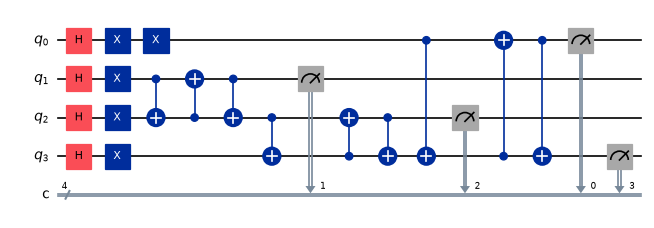


=== 2. Bernstein-Vazirani ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],[1,1,1,"X"],[1,1,1,"H"],["•",1,1,"X"],[1,"•",1,"X"],[1,1,"•","X"],["H","H","H"],["Measure","Measure","Measure"]]}


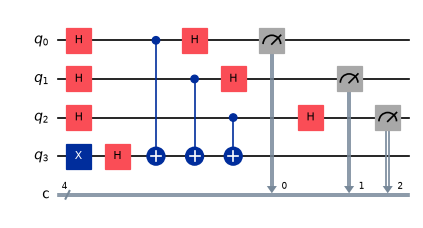


=== 3. Grover ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H"],[1,"X"],[1,"H"],["•","X"],[1,"H"],[1,"X"],[1,"H"],[1,"Measure"]]}


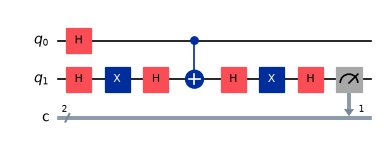


=== 4. Deutsch-Jozsa ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],["X",1,"X","X"],[1,1,1,"H"],["•",1,1,"X"],[1,"•",1,"X"],[1,1,"•","X"],["X",1,"X"],["H","H","H"],["Measure","Measure","Measure"]]}


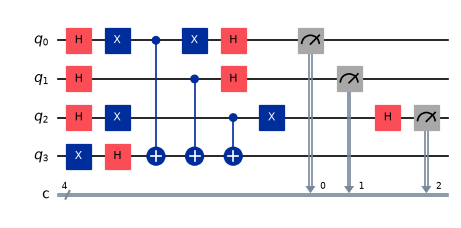


=== 5. Simon ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],["•",1,1,"X"],[1,"•",1,1,"X"],[1,1,"•",1,1,"X"],[1,"•",1,1,"X"],[1,"•",1,1,1,"X"],["H","H","H"],["Measure","Measure","Measure"]]}


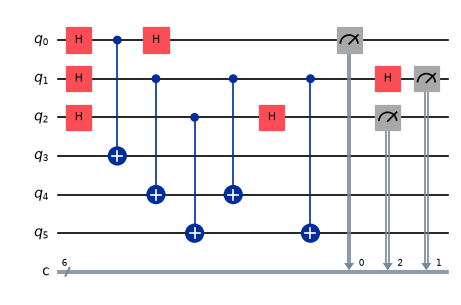


=== 6. TSP ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H"],[1,"X","X"],["X","•"],["X",1,"•"],["H"],["Measure","Measure","Measure"]]}


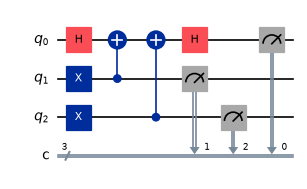


=== 7. Teleportation ===
Quirk: https://algassert.com/quirk#circuit={"cols":[[1,"H"],[1,"•",1,1,"X"],["H"],["•","X"],["H"],["Measure","Measure"],[1,"•",1,1,"X"],["•",1,1,1,"Z"]]}


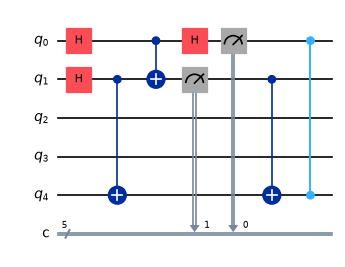


=== 8. Phase Estimation ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],[1,1,1,"X"],["•",1,1,"Z^¼"],[1,"•",1,"Z^¼"],[1,"•",1,"Z^¼"],[1,1,"•","Z^¼"],[1,1,"•","Z^¼"],[1,1,"•","Z^¼"],[1,1,"•","Z^¼"],["Swap",1,"Swap"],["H"],["•","~16c9"],[1,"H"],["•",1,"~gf1o"],[1,"•","~16c9"],[1,1,"H"],["Measure","Measure","Measure"]],"gates":[{"id":"~gf1o","name":"U(-pi/4)","matrix":"{{1,0},{0,√½-√½i}}"},{"id":"~16c9","name":"U(-pi/2)","matrix":"{{1,0},{0,-i}}"}]}


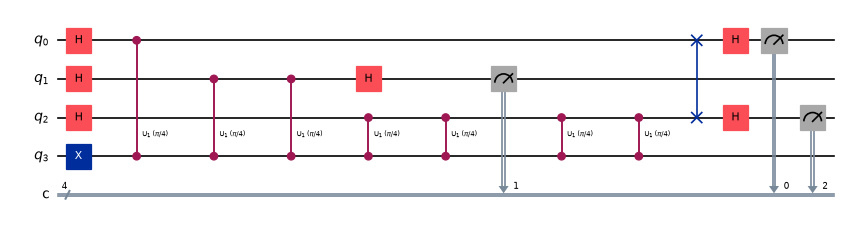


=== 9. QFT ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],[1,"X","X"],["H"],["Z","•"],["Z^½",1,"•"],[1,"H"],[1,"Z","•"],[1,1,"H"]]}


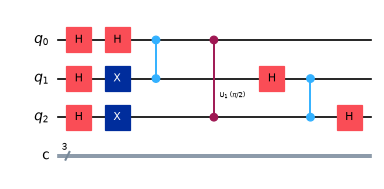


=== 10. QAOA ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["Rxft","Rxft"],[],["•","X"],["Rxft","Rxft"],[],[1,"Rxft"],[],["•","X"],["Rxft"],[],[1,"Measure"],["Measure"]]}


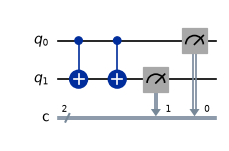


=== 11. Kickback ===
Quirk: https://algassert.com/quirk#circuit={"cols":[[1,"X"],["H","H"],["•","X"],["H","H"],["Measure"],[1,"Measure"]]}


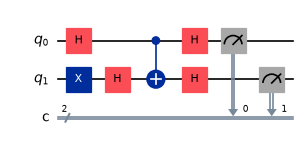


=== 12. Full Adder ===
Quirk: https://algassert.com/quirk#circuit={"cols":[["H","H","H"],["•","•",1,"X"],["•","X"],[1,"•","•","X"],[1,"•","X"],["•","X"],["Measure"],[1,"Measure"],[1,1,"Measure"],[1,1,1,"Measure"]]}


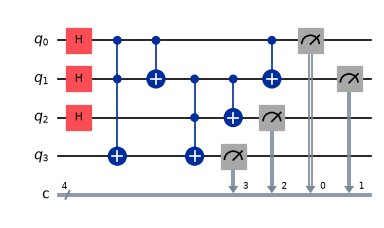

In [10]:
# @title 8. Mostrar TODOS los algoritmos en Qiskit
from urllib.parse import unquote
from IPython.display import display, HTML
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer

for name, algo in ALGORITHMS.items():
    print(f"=== {name} ===")
    print("Quirk:", unquote(algo["url"]))
    display(HTML('<a href="' + encode_quirk_url(algo["url"]) + '" target="_blank">Abrir en Quirk</a>'))
    qasm = quirk_to_qasm(algo["url"], algo["offset"])
    qc = QuantumCircuit.from_qasm_str(qasm)
    display(circuit_drawer(qc, output='mpl', scale=0.6))
    print()


In [ ]:
# @title 9. Simular y ver resultados
try:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator

    qc = QuantumCircuit.from_qasm_str(qasm)
    sim = AerSimulator()

    # Contar cuántas mediciones hay
    n_meas = sum(1 for line in qasm.split('\n') if 'measure' in line)
    shots = 1024 if n_meas > 0 else 1

    if n_meas > 0:
        result = sim.run(qc, shots=shots).result()
        counts = result.get_counts()
        print(f"Resultados ({shots} shots):")
        from qiskit.visualization import plot_histogram
        display(plot_histogram(counts))
    else:
        # Sin mediciones: mostrar matriz unitaria
        from qiskit.quantum_info import Operator
        unitary = Operator(qc).data
        import numpy as np
        np.set_printoptions(precision=3, suppress=True)
        print("Matriz unitaria:")
        print(unitary)
except ImportError:
    print("qiskit o qiskit-aer no están instalados.")
except Exception as e:
    print(f"Error: {e}")

Matriz unitaria:
[[1.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]


In [6]:
# @title 10. Probar URL personalizada
CUSTOM_URL = "https://algassert.com/quirk#circuit={'cols':[['H'],['•','X'],['Measure','Measure']]}"  # @param {type:"string"}
CUSTOM_OFFSET = 0  # @param {type:"integer"}

try:
    qasm = quirk_to_qasm(CUSTOM_URL, CUSTOM_OFFSET)
    print(qasm)
except Exception as e:
    print(f"Error: {e}")

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];


In [ ]:
parse_quirk_url("https://algassert.com/quirk#circuit={%22cols%22:[[%22X%22,1,%22X%22],[%22Swap%22,1,%22Swap%22],[%22Z%22,%22%E2%80%A2%22,%22%E2%80%A2%22]]}")

{'cols': [['X', 1, 'X'], ['Swap', 1, 'Swap']]}

In [7]:
encode_quirk_url("https://algassert.com/quirk#circuit={%22cols%22:[[%22X%22,1,%22X%22],[%22Swap%22,1,%22Swap%22],[%22Z%22,%22%E2%80%A2%22,%22%E2%80%A2%22]]}")


'https://algassert.com/quirk#circuit=%7B%22cols%22%3A%5B%5B%22X%22%2C1%2C%22X%22%5D%2C%5B%22Swap%22%2C1%2C%22Swap%22%5D%2C%5B%22Z%22%2C%22%E2%80%A2%22%2C%22%E2%80%A2%22%5D%5D%7D'

In [ ]:
try:
    qasm = quirk_to_qasm("https://algassert.com/quirk#circuit={%22cols%22:[[%22X%22,%22%E2%80%A2%22,%22%E2%80%A2%22,%22%E2%80%A2%22,%22%E2%80%A2%22]]}", 0)
    print(qasm)
except Exception as e:
    print(f"Error: {e}")

OPENQASM 2.0;
include "qelib1.inc";
qreg q[5];
creg c[5];



: 

In [ ]:
curl -X POST "http://localhost:8081/code/ibm/individual" -H "Content-Type: application/json" -d '{"url": "https://algassert.com/quirk#circuit={%22cols%22:[[%22X%22,%22%E2%80%A2%22,%22%E2%80%A2%22]]}"}'